In [1]:
import os
import PIL
import glob
import random
import numpy as np
import tensorflow as tf
import matplotlib.cm as cm
import matplotlib.pyplot as plt

from keras import layers, models
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

I0000 00:00:1778951267.316909  214308 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778951267.318709  214308 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778951267.501374  214308 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778951269.798563  214308 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

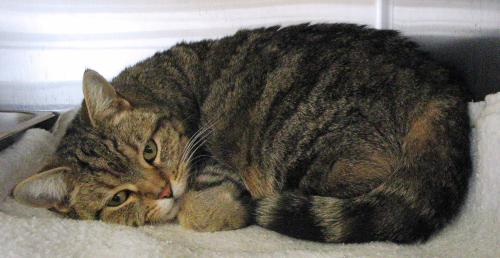

In [2]:
PIL.Image.open('PetImages/Cat/76.jpg')

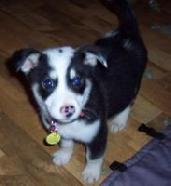

In [3]:
PIL.Image.open('PetImages/Dog/76.jpg')

In [7]:
# Correctly import from your local script
from Cleaning_DataSet import clean_fake_formats, base_dir
clean_fake_formats(base_dir)

# Run the signature scan
clean_fake_formats(base_dir)

# --- DATASET SETTINGS ---
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# --- ROBUST PYTHON PREPROCESSING FUNCTION ---
def preprocess_image_python(path_bytes):
    """Loads image with PIL and guarantees it has 3 channels (RGB)"""
    path = path_bytes.numpy().decode('utf-8')
    from PIL import Image as PILImage
    
    try:
        img = PILImage.open(path)
        # Convert to RGB if it isn't already
        if img.mode != 'RGB':
            img = img.convert('RGB')
        # Convert to numpy array
        img_array = np.array(img, dtype=np.uint8)
        return img_array
    except:
        # If it fails, fallback to a solid black image to prevent graph execution crashes
        return np.zeros((150, 150, 3), dtype=np.uint8)

def load_image_safe(path, label):
    """Loads image safely using a TensorFlow python function wrapper"""
    img = tf.py_function(preprocess_image_python, [path], tf.uint8)
    img.set_shape((150, 150, 3))  # Explicitly define the tensor shape
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

# Collect all image paths with their respective labels using glob
cat_files = glob.glob(f'{base_dir}/Cat/*')
dog_files = glob.glob(f'{base_dir}/Dog/*')

# Create path/label pairings (Cat = 0, Dog = 1)
all_files = [(f, 0) for f in cat_files] + [(f, 1) for f in dog_files]

# Shuffle and split into training and validation sets
random.seed(123)
random.shuffle(all_files)

split_idx = int(len(all_files) * 0.8)
train_files = all_files[:split_idx]
val_files = all_files[split_idx:]

# Create TensorFlow pipeline datasets from raw tensors
train_ds = tf.data.Dataset.from_tensor_slices((
    [f[0] for f in train_files],
    [f[1] for f in train_files]
))
train_ds = train_ds.map(load_image_safe, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((
    [f[0] for f in val_files],
    [f[1] for f in val_files]
))
val_ds = val_ds.map(load_image_safe, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("✓ Dataset created successfully!")
print(f"   - Training images: {len(train_files)}")
print(f"   - Validation images: {len(val_files)}")
print(f"   - Total files found: {len(all_files)}")

Starting file signature scan (Magic Bytes)...

[Scan Completed]
Images analyzed: 24932
Fake or corrupted files deleted: 0
Images converted to RGB: 0
Starting file signature scan (Magic Bytes)...

[Scan Completed]
Images analyzed: 24932
Fake or corrupted files deleted: 0
Images converted to RGB: 0
✓ Dataset created successfully!
   - Training images: 19947
   - Validation images: 4987
   - Total files found: 24934


## OBS: You'll find some corrupted and images coverted because I've aldeary treated before publish on github! But, don't worry, the code will work!

In [8]:
# 1. Auto mapping
class_names = ['Cat', 'Dog']
print("Class Mapping:")
for index, name in enumerate(class_names):
    print(f"Classe {index} ──> {name}")

Class Mapping:
Classe 0 ──> Cat
Classe 1 ──> Dog


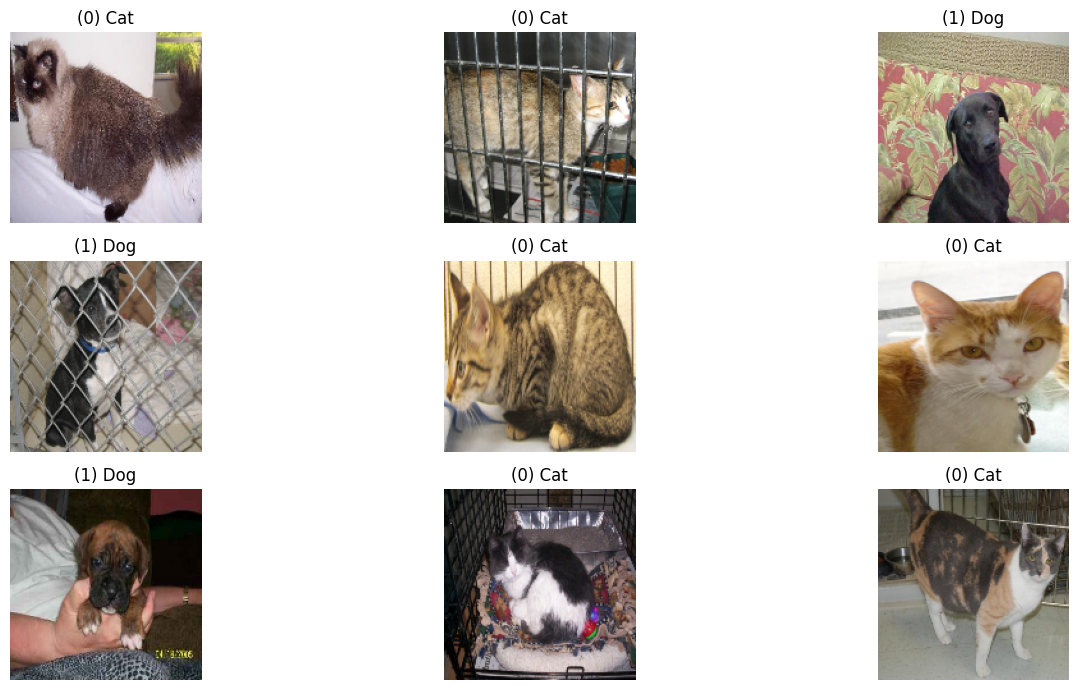

In [ ]:
plt.figure(figsize=(15, 7))

# Takes 1 batch from dataset train
for images, labels in train_ds.take(1):
    # Convert tensors to arrays by numpy
    images = images.numpy()
    labels = labels.numpy()
    
    # Sample 9 Index based on their real size -> BATCH_SIZE (32)
    indices_aleatorios = random.sample(range(len(images)), k=9)
    
    for posicao_grid, idx in enumerate(indices_aleatorios):
        plt.subplot(3, 3, posicao_grid + 1)
        plt.imshow(images[idx].astype('uint8'))
        
        # Takes int label value (0 ou 1) using int() to remove matriz format [[x]]
        label_inteira = int(labels[idx])
        nome_classe = class_names[label_inteira]
        
        plt.title(f'({label_inteira}) {nome_classe}')
        plt.axis('off')

plt.tight_layout()
plt.show()

In [22]:
EPOCHS = 17  # 30 epochs is a great window to see the learning curves develop

# --- DATA AUGMENTATION LAYER ---
# Dynamically creates variations of images to fight overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# --- BUILDING THE PROTECTED CNN MODEL ---
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    data_augmentation,  # Applies visual modifications to training images on-the-fly
    layers.Rescaling(1./255),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),  # 50% chance to drop out dense neurons to prevent rote memorization
    layers.Dense(1, activation='sigmoid')
])

# Compile using binary crossentropy since we are classifying 2 classes (Cats=0, Dogs=1)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- TRAINING THE MODEL ---
# Using the safe custom datasets built in the previous cell
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# Convert metrics history to a DataFrame for your statistical plotting scripts
history_df = pd.DataFrame(history.history)
history_df.index.name = 'epoch'

Epoch 1/17
178/624 ━━━━━━━━━━━━━━━━━━━━ 1:41 227ms/step - accuracy: 0.5328 - loss: 0.8923

/home/davvi/Programing/Projetos_Pessoais/Data_Analysis/cnn/venv_cnn/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


624/624 ━━━━━━━━━━━━━━━━━━━━ 184s 292ms/step - accuracy: 0.6199 - loss: 0.6673 - val_accuracy: 0.6840 - val_loss: 0.6131
Epoch 2/17
624/624 ━━━━━━━━━━━━━━━━━━━━ 197s 316ms/step - accuracy: 0.6886 - loss: 0.5904 - val_accuracy: 0.7433 - val_loss: 0.5272
Epoch 3/17
624/624 ━━━━━━━━━━━━━━━━━━━━ 184s 295ms/step - accuracy: 0.7168 - loss: 0.5583 - val_accuracy: 0.7620 - val_loss: 0.5069
Epoch 4/17
624/624 ━━━━━━━━━━━━━━━━━━━━ 188s 301ms/step - accuracy: 0.7375 - loss: 0.5312 - val_accuracy: 0.7762 - val_loss: 0.4708
Epoch 5/17
624/624 ━━━━━━━━━━━━━━━━━━━━ 190s 305ms/step - accuracy: 0.7541 - loss: 0.5083 - val_accuracy: 0.7766 - val_loss: 0.4635
Epoch 6/17
624/624 ━━━━━━━━━━━━━━━━━━━━ 186s 298ms/step - accuracy: 0.7621 - loss: 0.4942 - val_accuracy: 0.7963 - val_loss: 0.4377
Epoch 7/17
624/624 ━━━━━━━━━━━━━━━━━━━━ 189s 304ms/step - accuracy: 0.7728 - loss: 0.4802 - val_accuracy: 0.7955 - val_loss: 0.4477
Epoch 8/17
624/624 ━━━━━━━━━━━━━━━━━━━━ 185s 297ms/step - accuracy: 0.7791 - loss: 0.47

In [45]:
import glob
import tensorflow as tf

# --- CONFIGURAÇÃO DA PASTA DE TESTE EXTERNA ---
# Substitua pelo caminho da sua pasta com as 10 fotos (pode ser relativo ou absoluto)
PASTA_NOVAS_FOTOS = "random_photos/"

# Coleta todos os arquivos de imagem dentro dessa pasta usando o glob
# O asterisco '*' indica que ele vai pegar tudo o que estiver lá dentro
novos_arquivos = glob.glob(f'{PASTA_NOVAS_FOTOS}/*')

# Filtra para garantir que pegamos apenas arquivos com extensões de imagem válidas
novos_arquivos = [f for f in novos_arquivos if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Cria o pipeline do TensorFlow apenas com os caminhos dos arquivos
# Como são fotos novas sem rótulo, passamos uma "label dummy" (ex: 0) só para manter a estrutura da função
dataset_novas_fotos = tf.data.Dataset.from_tensor_slices((
    novos_arquivos,
    [0] * len(novos_arquivos)  # Cria uma lista de zeros com o mesmo tamanho da lista de fotos
))

# Aplica a mesma função 'load_image_safe' que você já definiu no seu Notebook
# Isso garante que se alguma das 10 fotos tiver canais errados ou bytes corrompidos, ela não trave
dataset_novas_fotos = dataset_novas_fotos.map(load_image_safe, num_parallel_calls=tf.data.AUTOTUNE)

# Define o tamanho do lote. Como são apenas 10 imagens, um batch_size de 10 processa todas de uma vez só!
dataset_novas_fotos = dataset_novas_fotos.batch(len(novos_arquivos))

print(f"✓ Pipeline de teste criado com sucesso!")
print(f"   - Imagens detectadas e prontas para inferência: {len(novos_arquivos)}")

✓ Pipeline de teste criado com sucesso!
   - Imagens detectadas e prontas para inferência: 15


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


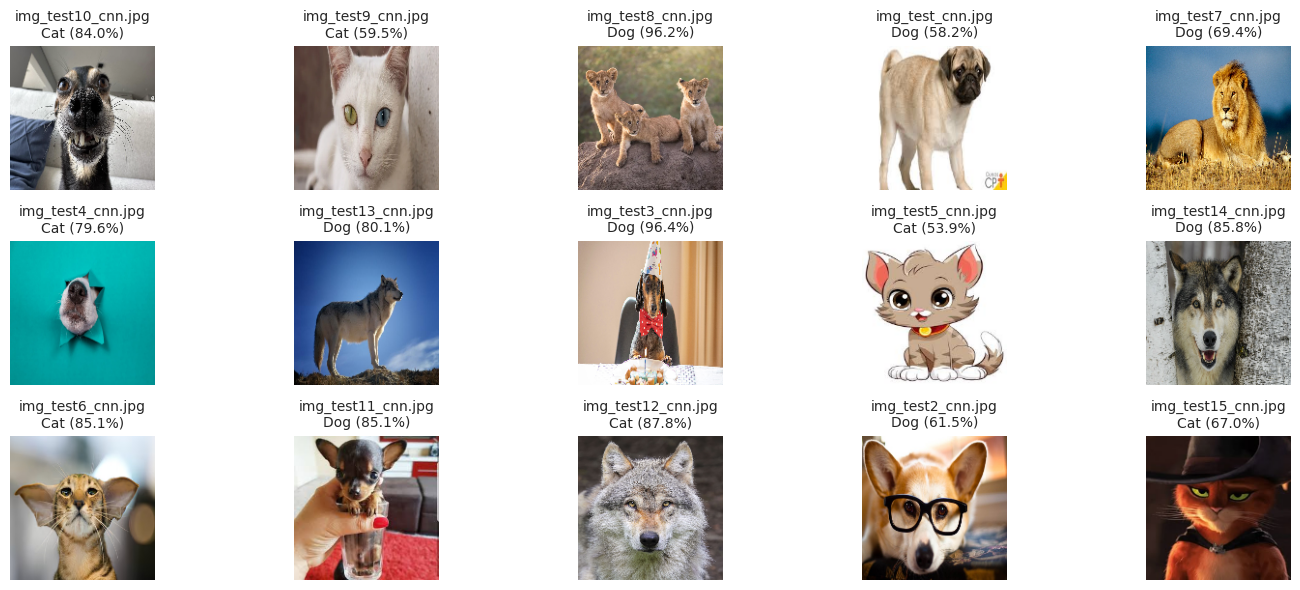

In [46]:
import matplotlib.pyplot as plt

class_names = ['Cat', 'Dog']

# Extrai o único lote contendo as 10 imagens prontas
for images, _ in dataset_novas_fotos.take(1):
    # O modelo faz a previsão de todas as 10 imagens simultaneamente em altíssima velocidade
    predictions = model.predict(images)
    
    # Prepara o tamanho do grid dependendo de quantas imagens realmente foram carregadas
    plt.figure(figsize=(15, 6))
    
    for idx, caminho_foto in enumerate(novos_arquivos):
        plt.subplot(3, 5, idx + 1) # Cria um grid de 2 linhas e 5 colunas (total 10)
        
        # Exibe a imagem original convertida de tensor para uint8
        plt.imshow(images[idx].numpy().astype('uint8'))
        
        # Extrai o score individual da imagem atual
        score = predictions[idx][0]
        
        # Define a classe e calcula a porcentagem de certeza
        if score < 0.5:
            nome_classe = class_names[0]
            certeza = (1 - score) * 100
        else:
            nome_classe = class_names[1]
            certeza = score * 100
            
        # Pega apenas o nome do arquivo (ex: "foto1.jpg") para o título não ficar gigante
        nome_arquivo_curto = caminho_foto.split('/')[-1]
        
        plt.title(f"{nome_arquivo_curto}\n{nome_classe} ({certeza:.1f}%)", fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()

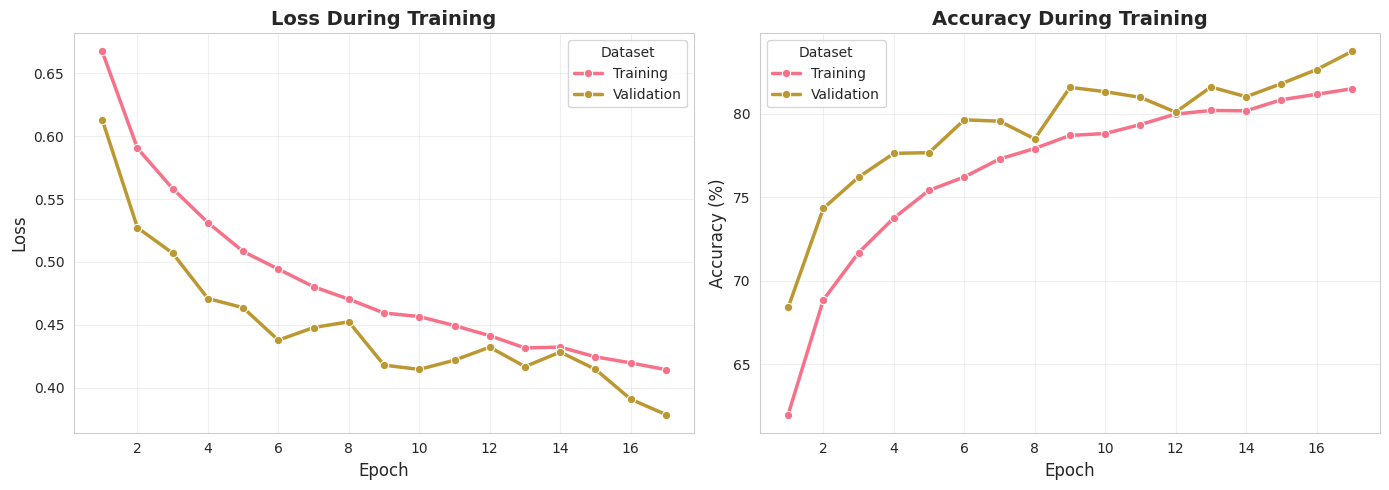


TRAINING SUMMARY

Initial Loss:      0.6673
Final Loss:        0.4143
Reduction:         37.93%

Initial Accuracy:  61.99%
Final Accuracy:    81.49%
Improvement:       19.50%

Validation Accuracy: 83.72%


In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
# Set Seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")

# Convert history to DataFrame for Seaborn usage
history_df = pd.DataFrame(history.history)
history_df['epoch'] = range(1, len(history_df) + 1)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
loss_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss': history_df['loss'],
    'Type': 'Training'
})
val_loss_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Loss': history_df['val_loss'],
    'Type': 'Validation'
})
combined_loss = pd.concat([loss_data, val_loss_data], ignore_index=True)

sns.lineplot(data=combined_loss, x='Epoch', y='Loss', hue='Type', 
             ax=axes[0], linewidth=2.5, marker='o', markersize=6)
axes[0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Dataset')

# Plot 2: Accuracy
acc_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Accuracy': history_df['accuracy'] * 100,
    'Type': 'Training'
})
val_acc_data = pd.DataFrame({
    'Epoch': history_df['epoch'],
    'Accuracy': history_df['val_accuracy'] * 100,
    'Type': 'Validation'
})
combined_acc = pd.concat([acc_data, val_acc_data], ignore_index=True)

sns.lineplot(data=combined_acc, x='Epoch', y='Accuracy', hue='Type', 
             ax=axes[1], linewidth=2.5, marker='o', markersize=6)
axes[1].set_title('Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Dataset')

plt.tight_layout()
plt.show()

# Training summary
print("\n" + "=" * 80)
print("TRAINING SUMMARY")
print("=" * 80)
print(f"\nInitial Loss:      {history.history['loss'][0]:.4f}")
print(f"Final Loss:        {history.history['loss'][-1]:.4f}")
print(f"Reduction:         {((history.history['loss'][0] - history.history['loss'][-1]) / history.history['loss'][0] * 100):.2f}%")

print(f"\nInitial Accuracy:  {history.history['accuracy'][0]*100:.2f}%")
print(f"Final Accuracy:    {history.history['accuracy'][-1]*100:.2f}%")
print(f"Improvement:       {(history.history['accuracy'][-1] - history.history['accuracy'][0])*100:.2f}%")

print(f"\nValidation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print("=" * 80)

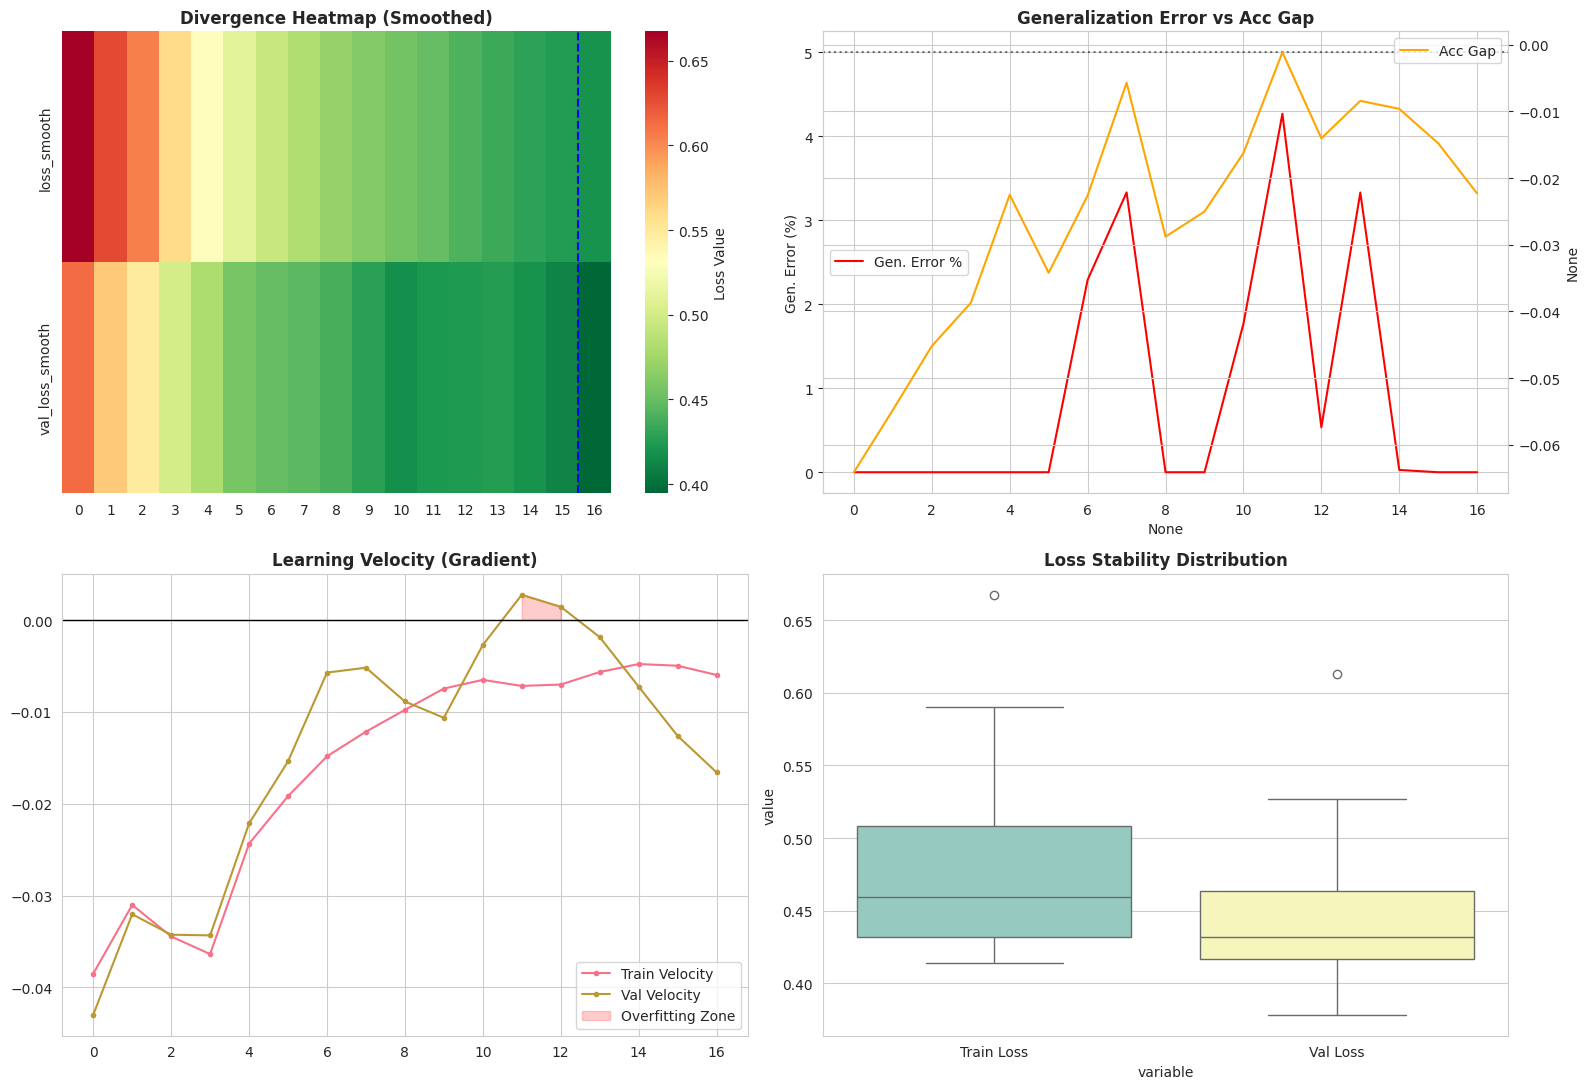


STATISTICAL OVERFITTING REPORT
Best epoch found: 16
No critical signs of overfitting detected within limits.
STATUS: ✓ STABLE MODEL
Final_Gap: -3.57%


In [48]:
# --- Data Preparation ---
# Assuming 'history_df' exists with columns: loss, val_loss, accuracy, val_accuracy
df = history_df.copy()

# 1. Smoothing (Rolling Mean) to avoid false positives caused by noise
window = 3
df['loss_smooth'] = df['loss'].rolling(window=window, min_periods=1).mean()
df['val_loss_smooth'] = df['val_loss'].rolling(window=window, min_periods=1).mean()

# 2. Generalization Error Calculation (G)
# G = 100 * (current val_loss / min val_loss so far - 1)
min_val_loss_so_far = df['val_loss'].cummin()
df['generalization_error'] = 100 * (df['val_loss'] / min_val_loss_so_far - 1)

# 3. Inflection Point Identification (Where overfitting actually begins)
best_epoch = df['val_loss'].idxmin()
overfit_epoch = df[(df.index > best_epoch) & (df['generalization_error'] > 5)].index.min()

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Plot 1: Smoothed Loss Heatmap (Focused on Divergence)
metrics_heatmap = df[['loss_smooth', 'val_loss_smooth']].T
sns.heatmap(metrics_heatmap, cmap='RdYlGn_r', ax=axes[0, 0], cbar_kws={'label': 'Loss Value'})
axes[0, 0].set_title('Divergence Heatmap (Smoothed)', fontweight='bold')
axes[0, 0].axvline(x=best_epoch, color='blue', linestyle='--', label='Best Model')

# Plot 2: Accuracy Gap and Generalization Error
ax2_twin = axes[0, 1].twinx()
sns.lineplot(data=df, x=df.index, y='generalization_error', ax=axes[0, 1], color='red', label='Gen. Error %')
sns.lineplot(data=df, x=df.index, y=df['accuracy'] - df['val_accuracy'], ax=ax2_twin, color='orange', label='Acc Gap')
axes[0, 1].axhline(y=5, color='black', linestyle=':', alpha=0.5) # 5% Threshold
axes[0, 1].set_title('Generalization Error vs Acc Gap', fontweight='bold')
axes[0, 1].set_ylabel('Gen. Error (%)')

# Plot 3: Loss Derivative (Learning Velocity)
train_diff = np.gradient(df['loss_smooth'])
val_diff = np.gradient(df['val_loss_smooth'])
axes[1, 0].plot(df.index, train_diff, label='Train Velocity', marker='o', markersize=3)
axes[1, 0].plot(df.index, val_diff, label='Val Velocity', marker='o', markersize=3)
axes[1, 0].axhline(y=0, color='black', lw=1)
axes[1, 0].fill_between(df.index, val_diff, where=(val_diff > 0), color='red', alpha=0.2, label='Overfitting Zone')
axes[1, 0].set_title('Learning Velocity (Gradient)', fontweight='bold')
axes[1, 0].legend()

# Plot 4: Relative Error Distribution
error_dist = pd.DataFrame({
    'Train Loss': df['loss'],
    'Val Loss': df['val_loss']
}).melt()
sns.boxplot(data=error_dist, x='variable', y='value', ax=axes[1, 1], palette='Set3', hue='variable', legend=False)
axes[1, 1].set_title('Loss Stability Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

# --- Enhanced Final Report ---
print("\n" + "=" * 50)
print("STATISTICAL OVERFITTING REPORT")
print("=" * 50)
print(f"Best epoch found: {best_epoch}")
if not np.isnan(overfit_epoch):
    print(f"Critical overfitting detected at epoch: {overfit_epoch}")
    print(f"Validation degradation since minimum: {df['generalization_error'].iloc[-1]:.2f}%")
else:
    print("No critical signs of overfitting detected within limits.")

# Severity Criteria
final_gap = df['val_loss'].iloc[-1] - df['loss'].iloc[-1]
if final_gap > 0.5:
    print(f'Final_Gap: {final_gap*100:.2f}%')
    print("STATUS: ✗ SEVERE OVERFITTING - Complexity reduction or dropout required.")
elif final_gap > 0.2:
    print("STATUS: ⚠ MODERATE OVERFITTING - Consider Early Stopping.")
    print(f'Final_Gap: {final_gap*100:.2f}%')
else:
    print("STATUS: ✓ STABLE MODEL")
    print(f'Final_Gap: {final_gap*100:.2f}%')